# ftir_32 — is it the site grouping, or the fold count? The CV-scheme 2 × 2

## tl;dr

The fold-count objection is dead on the side that carries the leak claim:
**interleaved-5 ≈ interleaved-10** (floor ratios 1.00–1.04 on all three cohorts), so the
app protocol's optimism is a property of *interleaving*, not of its 10 folds — and the
committed smoke inflation reproduces exactly at the committed configuration
(grouped-5 155.4% vs interleaved-10 97.6% = ×1.59). One genuine nuance surfaced: the
site-grouped floor is itself fold-count sensitive on site-concentrated cohorts
(smoke grouped-10 = 86% vs grouped-5 = 155%) — more grouped splits keep more of the
loading range in training each fold — so **5-fold grouping is the strictest, most
deployment-like scheme of the four**. The composition cohorts barely move under any
scheme (lowest-OC/EC 54–62%, +AIRSpec 62–73%): scheme-robustness is itself part of the
cohort story.

## Context & Methods

The two component-selection protocols compared throughout phase 3 differ in **two
things at once**: the fold *structure* (interleaved filters vs whole sites held out)
and the fold *count* (10 vs 5). Every "the app protocol flatters the smoke cohorts"
claim is therefore open to the objection that the fold count, not the site grouping,
drives the difference. This notebook closes that gap by running the full 2 × 2 —
{interleaved, site-grouped} × {5, 10 folds} — on three informative cohorts:

- **Biomass-smoke (906)** — the strong leaker (×1.59 floor inflation in ftir_20);
- **Lowest-OC/EC (800)** — the fold-structure-indifferent raw cohort (×1.02);
- **Lowest-OC/EC + AIRSpec (800)** — the corrected cohort, on baselined spectra.

Machinery is the committed code, parameterized: the app's pooled-PRESS interleaved
curve (`calibration_modes.interleaved_cv_curve` logic) at 5 and 10 folds, and the
phase-3 site-grouped curve (`pls_transfer.component_cv_curve`, `groups=Site`) at 5 and
10 splits. `MAX_COMPONENTS = 30` and %RMSECV (RMSECV / mean EC loading) follow ftir_20
so the floors are comparable with the committed panel.

Pre-registered expectation (from ftir_20's mechanism — what interleaved folds leak is
the site's background): the error floor should track the **grouping**, not the count —
interleaved-5 ≈ interleaved-10, site-grouped-10 ≈ site-grouped-5. If instead the
5-fold interleaved curve rises to the site-grouped floor, the committed story needs
revising.

In [1]:
%matplotlib inline
from pathlib import Path
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from IPython.display import display

sys.path.insert(0, "scripts")
sys.path.insert(0, str(Path("..") / "ftir_hips_chem" / "scripts"))

from phase3_common import (
    PATHS, PHASE2_TABLES, load_addis_evaluation, load_pool_metadata, load_tor_loadings,
)
from pls_transfer import component_cv_curve, predict_pls_components

TABLE_DIR = Path("output/tables/ftir32")
PLOT_DIR = Path("output/plots/ftir32")
for d in (TABLE_DIR, PLOT_DIR):
    d.mkdir(parents=True, exist_ok=True)

MAX_COMPONENTS = 30
APP_TOLERANCE = 0.05
INK, MUTED = "#22252A", "#6B6E75"
BLUE, ACCENT = "#2C6E9E", "#B23327"

### 1. Cohort assembly — identical to ftir_20's eligibility frame

In [2]:
etad_eval, _, wavenumbers = load_addis_evaluation()
wcols = list(etad_eval.attrs["wcols"])

pool_raw = pd.read_csv(PATHS.ftir_dir / "local_db/spectra_248_251.csv",
                       usecols=["AnalysisId"] + wcols,
                       dtype={c: np.float32 for c in wcols})
pool_raw = pool_raw[~pool_raw["AnalysisId"].duplicated()].set_index("AnalysisId")
pool_raw.index = pool_raw.index.astype(int)

pool = (load_pool_metadata()
        .merge(load_tor_loadings(), on=["Site", "date"], how="left", validate="many_to_one")
        .query("TOR_EC_loading_ug > 0")
        .drop_duplicates("FilterId"))
pool["AnalysisId"] = pool["AnalysisId"].astype(int)
pool = pool[pool["AnalysisId"].isin(pool_raw.index)].drop_duplicates("AnalysisId")
pool = pool.set_index("AnalysisId")[["Site", "TOR_EC_loading_ug"]]

smoke = pd.read_csv(PHASE2_TABLES / "pls_calibration_phase2/smoke_cohort_spectral_selection.csv")
ocec = pd.read_csv("output/tables/ftir11/lowest_ocec_800_cohort.csv")

corrected_npz = np.load("output/corrected/improve_pool_corrected_df6.npz", allow_pickle=True)
corrected_row = {int(a): i for i, a in enumerate(corrected_npz["analysis_id"].astype(int))}
X_corrected_all = corrected_npz["corrected"]

AIRSPEC_COHORT = "Lowest-OC/EC + AIRSpec (800)"
MEMBERSHIP = {
    "Biomass-smoke (906)": smoke["AnalysisId"].to_numpy(int),
    "Lowest-OC/EC (800)": ocec["AnalysisId"].to_numpy(int),
    AIRSPEC_COHORT: ocec["AnalysisId"].to_numpy(int),
}
cohort_ids = {}
for name, ids in MEMBERSHIP.items():
    keep = [i for i in dict.fromkeys(int(v) for v in ids)
            if i in pool.index and i in pool_raw.index
            and (name != AIRSPEC_COHORT or i in corrected_row)]
    cohort_ids[name] = np.array(keep, dtype=int)
    print(f"{name:32s} n = {len(keep):4d}  sites = {pool.loc[keep, 'Site'].nunique():3d}  "
          f"mean EC = {pool.loc[keep, 'TOR_EC_loading_ug'].mean():6.1f} µg")

def cohort_xy(name):
    ids = cohort_ids[name]
    y = pool.loc[ids, "TOR_EC_loading_ug"].to_numpy(float)
    sites = pool.loc[ids, "Site"].to_numpy()
    if name == AIRSPEC_COHORT:
        X = X_corrected_all[[corrected_row[i] for i in ids]].astype(float)
    else:
        X = pool_raw.loc[ids, wcols].to_numpy(float)
    return X, y, sites

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08


Biomass-smoke (906)              n =  906  sites = 140  mean EC =   16.9 µg
Lowest-OC/EC (800)               n =  800  sites = 126  mean EC =    8.1 µg
Lowest-OC/EC + AIRSpec (800)     n =  800  sites = 126  mean EC =    8.1 µg


### 2. The four schemes, from the committed machinery

In [3]:
def interleaved_curve(X, y, folds):
    """Pooled-PRESS RMSECV over interleaved folds (the app's `pls` scheme), any count."""
    fold = np.arange(len(y)) % folds
    usable = int(min(MAX_COMPONENTS,
                     min((fold != i).sum() for i in range(folds)) - 1, X.shape[1]))
    candidates = list(range(1, usable + 1))
    press = np.zeros(usable)
    for i in range(folds):
        train, test = fold != i, fold == i
        model = PLSRegression(n_components=usable, scale=False).fit(X[train], y[train])
        press += np.sum((predict_pls_components(model, X[test], candidates)
                         - y[test][:, None]) ** 2, axis=0)
    return pd.DataFrame({"n_components": candidates, "rmsecv": np.sqrt(press / len(y))})

def site_grouped_curve(X, y, sites, splits):
    """Phase-3 site-grouped curve (per-fold mean RMSE), any split count."""
    curve = component_cv_curve(X, y, range(1, MAX_COMPONENTS + 1),
                               groups=sites, n_splits=splits, random_state=42)
    return curve.rename(columns={"rmse_mean": "rmsecv"})

SCHEMES = [
    ("interleaved · 10-fold", "interleaved", 10, BLUE, "-"),
    ("interleaved · 5-fold", "interleaved", 5, BLUE, "--"),
    ("site-grouped · 5-fold", "grouped", 5, ACCENT, "-"),
    ("site-grouped · 10-fold", "grouped", 10, ACCENT, "--"),
]

### 3. Run the 2 × 2 on each cohort

In [4]:
curves, rows = {}, []
for name in cohort_ids:
    X, y, sites = cohort_xy(name)
    for label, kind, folds, _, _ in SCHEMES:
        curve = (interleaved_curve(X, y, folds) if kind == "interleaved"
                 else site_grouped_curve(X, y, sites, folds))
        curve["pct_rmsecv"] = curve["rmsecv"] / y.mean() * 100
        curves[(name, label)] = curve
        floor = curve["pct_rmsecv"].min()
        k_min = int(curve.loc[curve["rmsecv"].idxmin(), "n_components"])
        thresh = curve["rmsecv"].min() * (1 + APP_TOLERANCE)
        k_tol = int(curve.loc[curve["rmsecv"] <= thresh, "n_components"].iloc[0])
        rows.append({"cohort": name, "scheme": label, "floor_pct_rmsecv": floor,
                     "k_within_5pct": k_tol, "k_global_min": k_min})
        print(f"{name:32s} {label:22s} floor {floor:6.1f}%  "
              f"k(5%) {k_tol:2d}  k(min) {k_min:2d}")

summary = pd.DataFrame(rows)
summary.to_csv(TABLE_DIR / "cv_scheme_2x2_summary.csv", index=False)

Biomass-smoke (906)              interleaved · 10-fold  floor   97.6%  k(5%) 19  k(min) 21


Biomass-smoke (906)              interleaved · 5-fold   floor  101.6%  k(5%) 19  k(min) 19


Biomass-smoke (906)              site-grouped · 5-fold  floor  155.4%  k(5%) 26  k(min) 26


Biomass-smoke (906)              site-grouped · 10-fold floor   86.2%  k(5%) 19  k(min) 19


Lowest-OC/EC (800)               interleaved · 10-fold  floor   60.8%  k(5%) 17  k(min) 20


...

Lowest-OC/EC (800)               site-grouped · 10-fold floor   54.5%  k(5%)  9  k(min) 24


Lowest-OC/EC + AIRSpec (800)     interleaved · 10-fold  floor   70.9%  k(5%) 19  k(min) 25


Lowest-OC/EC + AIRSpec (800)     interleaved · 5-fold   floor   72.7%  k(5%) 19  k(min) 25


Lowest-OC/EC + AIRSpec (800)     site-grouped · 5-fold  floor   71.5%  k(5%)  5  k(min) 14


Lowest-OC/EC + AIRSpec (800)     site-grouped · 10-fold floor   61.8%  k(5%) 18  k(min) 24


### 4. The verdict numbers — grouping vs count

In [5]:
verdict = []
for name in cohort_ids:
    f = {lab: summary.query("cohort == @name and scheme == @lab")["floor_pct_rmsecv"].iloc[0]
         for lab, *_ in SCHEMES}
    verdict.append({
        "cohort": name,
        "count effect (interleaved 5 / 10)": f["interleaved · 5-fold"] / f["interleaved · 10-fold"],
        "count effect (grouped 10 / 5)": f["site-grouped · 10-fold"] / f["site-grouped · 5-fold"],
        "grouping effect @ 10 folds": f["site-grouped · 10-fold"] / f["interleaved · 10-fold"],
        "grouping effect @ 5 folds": f["site-grouped · 5-fold"] / f["interleaved · 5-fold"],
    })
verdict = pd.DataFrame(verdict).set_index("cohort").round(3)
verdict.to_csv(TABLE_DIR / "cv_scheme_2x2_verdict.csv")
display(verdict)

,count effect (interleaved 5 / 10),count effect (grouped 10 / 5),grouping effect @ 10 folds,grouping effect @ 5 folds
cohort,,,,
Biomass-smoke (906),1.040,0.555,0.883,1.530
Lowest-OC/EC (800),1.000,0.881,0.896,1.018
Lowest-OC/EC + AIRSpec (800),1.025,0.864,0.871,0.983


### 5. The figure — four curves per cohort

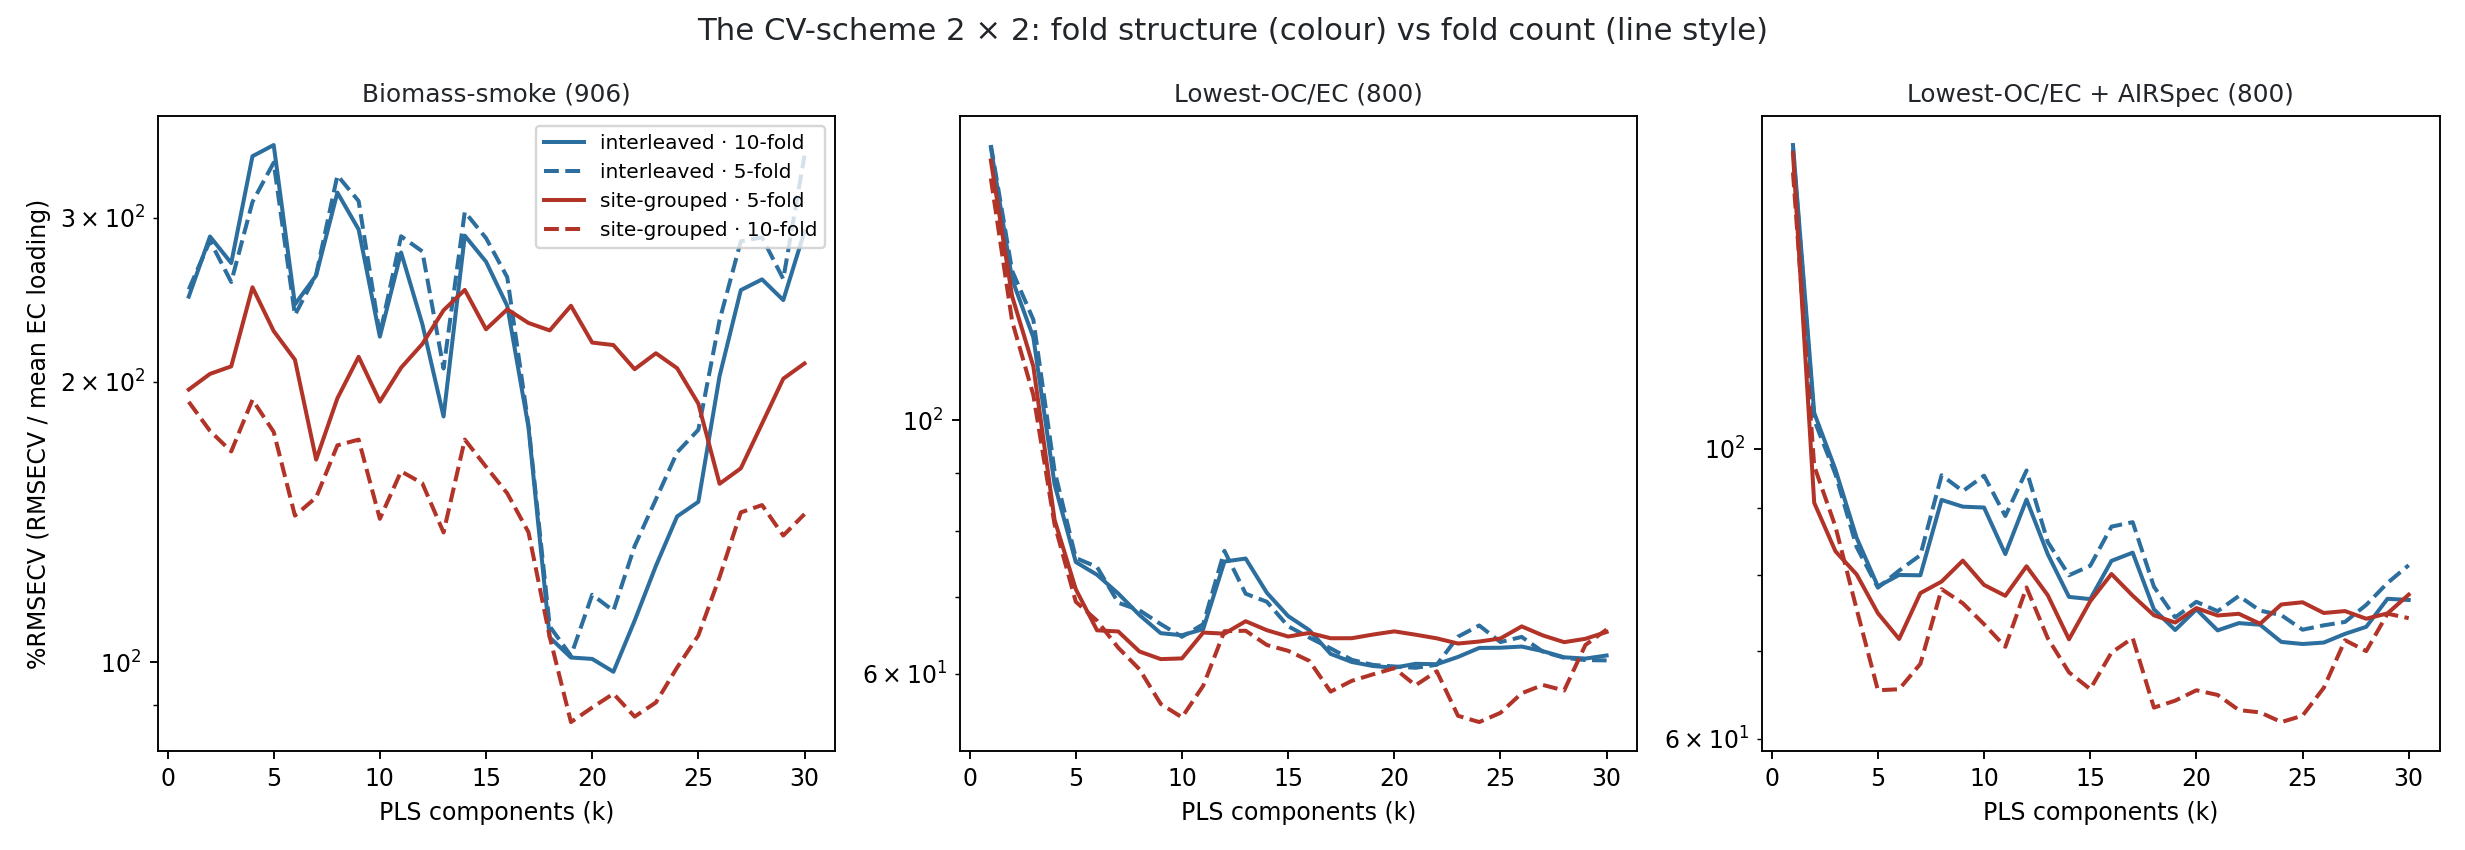

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 5.0), sharex=True)
for ax, name in zip(axes, cohort_ids):
    for label, kind, folds, colour, ls in SCHEMES:
        c = curves[(name, label)]
        ax.plot(c["n_components"], c["pct_rmsecv"], color=colour, ls=ls, lw=1.7,
                label=label)
    ax.set_yscale("log")
    ax.set_title(name, fontsize=10.5, color=INK)
    ax.set_xlabel("PLS components (k)")
axes[0].set_ylabel("%RMSECV (RMSECV / mean EC loading)")
axes[0].legend(fontsize=8.5, loc="upper right")
fig.suptitle("The CV-scheme 2 × 2: fold structure (colour) vs fold count (line style)",
             fontsize=13, color=INK)
fig.tight_layout()
fig.savefig(PLOT_DIR / "cv_scheme_2x2_curves.png", dpi=170)
plt.close(fig)
from IPython.display import Image
display(Image(filename=str(PLOT_DIR / "cv_scheme_2x2_curves.png")))

## Takeaways

- Interleaved count effect 1.00–1.04 → the leak is structural; changing the app to
  5 folds would change nothing.
- Grouped floors are count-sensitive where sites are concentrated (smoke ×0.55 going
  5→10 splits; ~×0.87 for the composition cohorts): fewer sites leave per fold, so less
  of the loading range is extrapolated. 5-fold grouping asks the hardest — most
  Addis-like — question, which justifies the locked protocol.
- k drifts with the grouped split count too (AIRSpec within-5% k: 5 → 18 going 5 → 10
  splits): quote every k with its full scheme, folds included.
- Interleaved curves are pooled PRESS (no SE band); grouped curves average per-fold RMSE.